# Features Pair Analysis: Correlation Matrix + Price Boxplots

流程：
1. 数据加载与基础预处理
2. 所有特征相关矩阵（类别特征先编码）
3. 每个特征与 `Price (€)` 的箱线图关系

# 1) 原始数据导入

In [1]:
# 单元功能：导入库并初始化绘图参数。
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

In [2]:
# 单元功能：读取训练数据并查看基础信息。
csv_path = 'ppr-group-25208508-train-lab3-preview.csv'
df = pd.read_csv(csv_path)

print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape}')
display(df.head(3))

Loaded: ppr-group-25208508-train-lab3-preview.csv
Shape: (54000, 11)


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,Sale Year,Sale Month
0,2016-09-30,"28 BRACKEN COURT, DONNYBROOK, CORK",Cork,NaN,181000.00,No,No,Second-Hand Dwelling house /Apartment,NaN,2016,9
1,2016-12-20,"2 AN CLOCHAR, CONVENT RD, DONERAILE",Cork,NaN,50152.49,No,Yes,New Dwelling house /Apartment,less than 38 sq metres,2016,12
2,2016-09-28,"Apartment 7 The Court, Clonattin, Gorey",Wexford,NaN,62171.81,No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,2016,9


In [3]:
# 单元功能：完成价格字段清洗、日期字段拆分，并构建分析数据集。
price_col = 'Price (€)'
if price_col not in df.columns:
    raise KeyError("Column 'Price (€)' not found in dataframe")

df[price_col] = pd.to_numeric(
    df[price_col].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

for c in df.columns:
    if 'date' in c.lower():
        dt = pd.to_datetime(df[c], dayfirst=True, errors='coerce')
        if dt.notna().sum() > 0:
            base = c.replace(' (dd/mm/yyyy)', '').replace(' ', '_')
            df[f'{base}_Year'] = dt.dt.year.astype('Int64')
            df[f'{base}_Month'] = dt.dt.month.astype('Int64')
            df[f'{base}_DayOfWeek'] = dt.dt.dayofweek.astype('Int64')

work = df.dropna(subset=[price_col]).copy()
print('Rows with valid price:', len(work))
print('Total columns in analysis set:', work.shape[1])

Rows with valid price: 54000
Total columns in analysis set: 14


/var/folders/jw/0ttqd5gn6_zf0xv62ypjvn9r0000gn/T/ipykernel_21271/4120468145.py:13: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(df[c], dayfirst=True, errors='coerce')


# 2) 特征对提取 - 相关矩阵（数值特征）

In [4]:
# 单元功能：仅保留指定特征并输出基础统计。
target = 'Price (€)'
requested_features = ['County', 'Sale Year', 'Sale Month', 'Description of Property']
selected_features = [c for c in requested_features if c in work.columns]
missing_features = [c for c in requested_features if c not in work.columns]

if missing_features:
    print('Missing features:', missing_features)

pair_rows = []
for c in selected_features:
    s = work[c]
    pair_rows.append({
        'Feature': c,
        'Type': 'numeric' if pd.api.types.is_numeric_dtype(s) else 'categorical',
        'NonNull': int(s.notna().sum()),
        'Unique': int(s.nunique(dropna=True))
    })

pair_df = pd.DataFrame(pair_rows)
display(pair_df)
print('Selected feature pairs:', len(pair_df))



,Feature,Type,NonNull,Unique
0,County,categorical,54000,26
1,Sale Year,numeric,54000,9
2,Sale Month,numeric,54000,12
3,Description of Property,categorical,54000,3


Selected feature pairs: 4


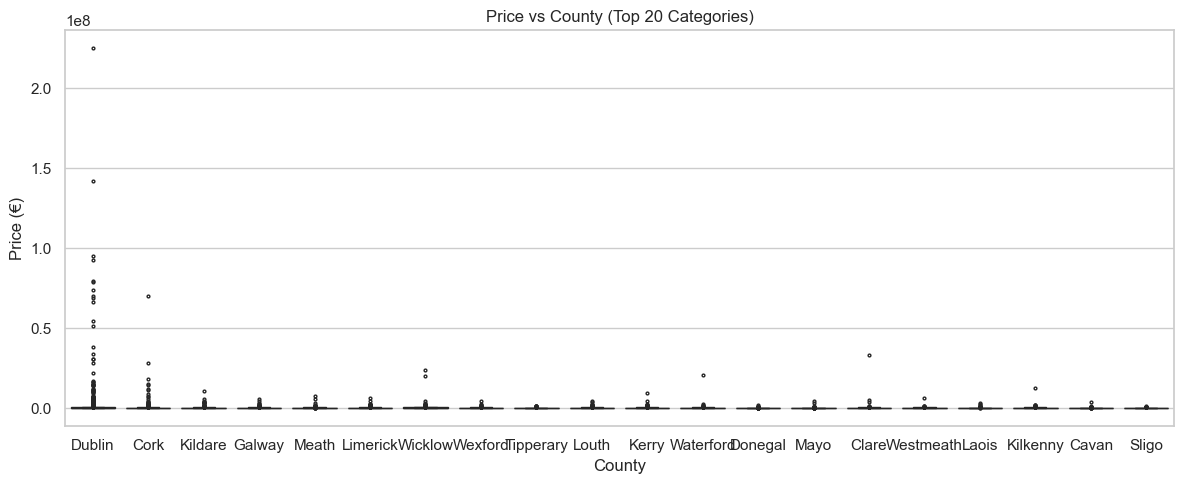

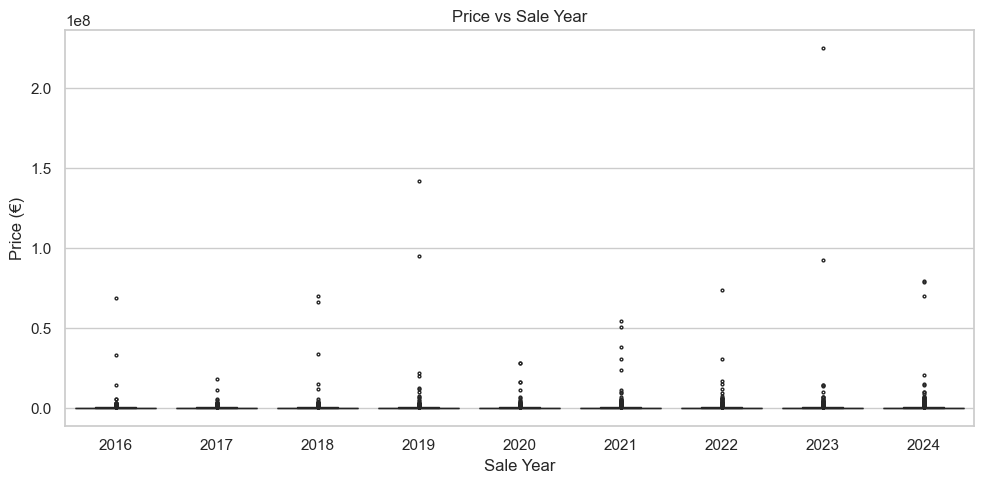

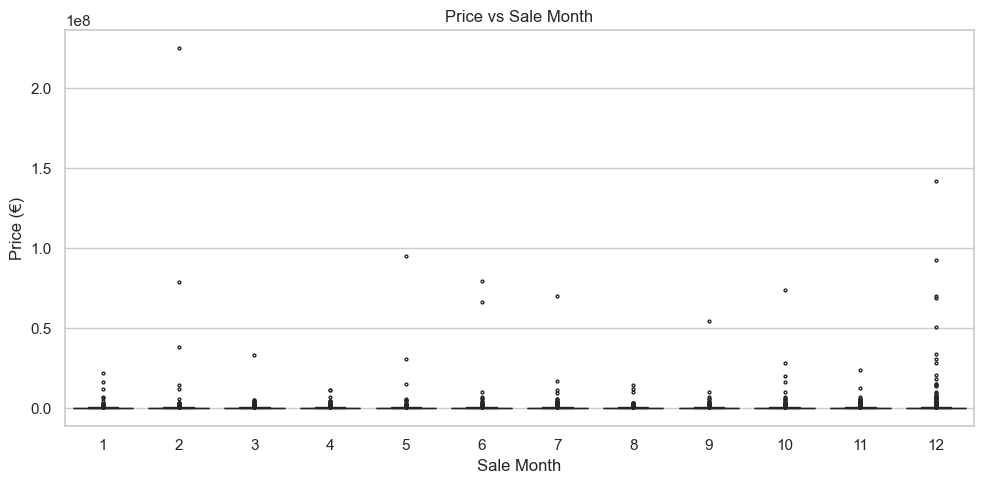

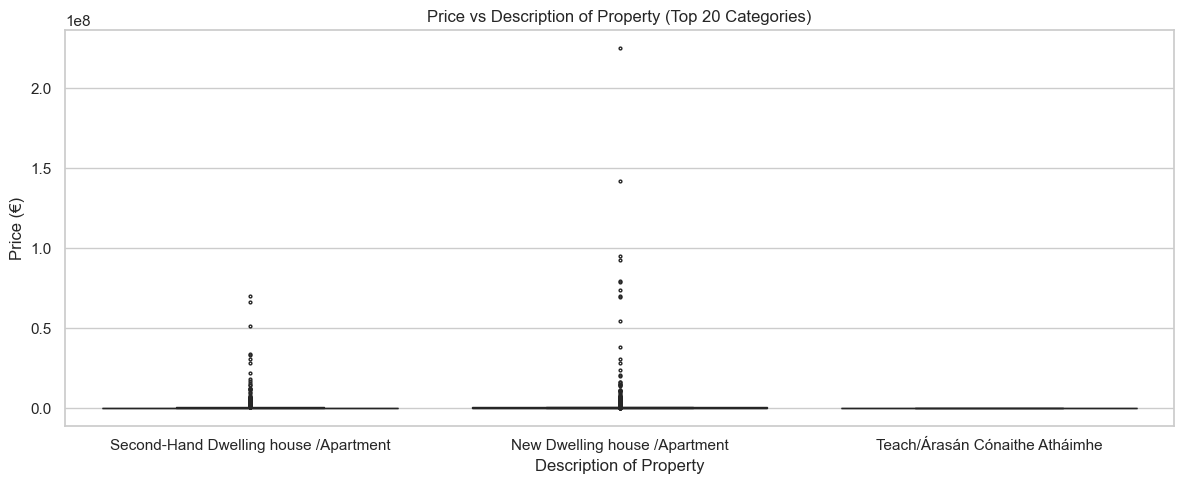

In [6]:
# 单元功能：对指定特征逐个绘制 Price 箱线图，并保存图片。
import re
from pathlib import Path
MAX_CATS = 20
MIN_NON_NULL = 50
PLOT_DIR = Path('feature_pair_plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plot_log = []

def _safe_name(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_')

for feature in selected_features:
    tmp = work[[target, feature]].dropna().copy()

    if len(tmp) < MIN_NON_NULL:
        plot_log.append({'Feature': feature, 'Status': 'skip', 'Reason': f'too few rows ({len(tmp)})', 'File': ''})
        continue

    if feature in ['Sale Year', 'Sale Month']:
        tmp[feature] = pd.to_numeric(tmp[feature], errors='coerce').astype('Int64')
        tmp = tmp.dropna(subset=[feature]).copy()
        tmp[feature] = tmp[feature].astype(int).astype(str)

        order = sorted(tmp[feature].unique(), key=lambda x: int(x))
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=tmp, x=feature, y=target, order=order, color='teal', fliersize=2)
        plt.title(f'Price vs {feature}')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.tight_layout()

        file_path = PLOT_DIR / f"boxplot_{_safe_name(feature)}_vs_{_safe_name(target)}.png"
        plt.savefig(file_path, dpi=180, bbox_inches='tight')
        plt.show()
        plt.close()

        plot_log.append({'Feature': feature, 'Status': 'plotted', 'Reason': 'direct integer-group boxplot', 'File': str(file_path)})
        continue

    vc = tmp[feature].value_counts(dropna=True)
    top_levels = vc.head(MAX_CATS).index
    tmp2 = tmp[tmp[feature].isin(top_levels)].copy()

    if tmp2[feature].nunique(dropna=True) < 2:
        plot_log.append({'Feature': feature, 'Status': 'skip', 'Reason': 'categories < 2', 'File': ''})
        continue

    order = tmp2[feature].value_counts().index
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=tmp2, x=feature, y=target, order=order, color='teal', fliersize=2)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Price vs {feature} (Top {MAX_CATS} Categories)')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.tight_layout()

    file_path = PLOT_DIR / f"boxplot_{_safe_name(feature)}_vs_{_safe_name(target)}.png"
    plt.savefig(file_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()

    plot_log.append({'Feature': feature, 'Status': 'plotted', 'Reason': 'categorical boxplot', 'File': str(file_path)})



# 3) clean data 特征对分析

,Feature,Type,NonNull,Unique
0,County,categorical,53991,26
1,Sale Year,categorical,53991,9
2,Sale Month,categorical,53991,12
3,Description of Property,categorical,53991,3


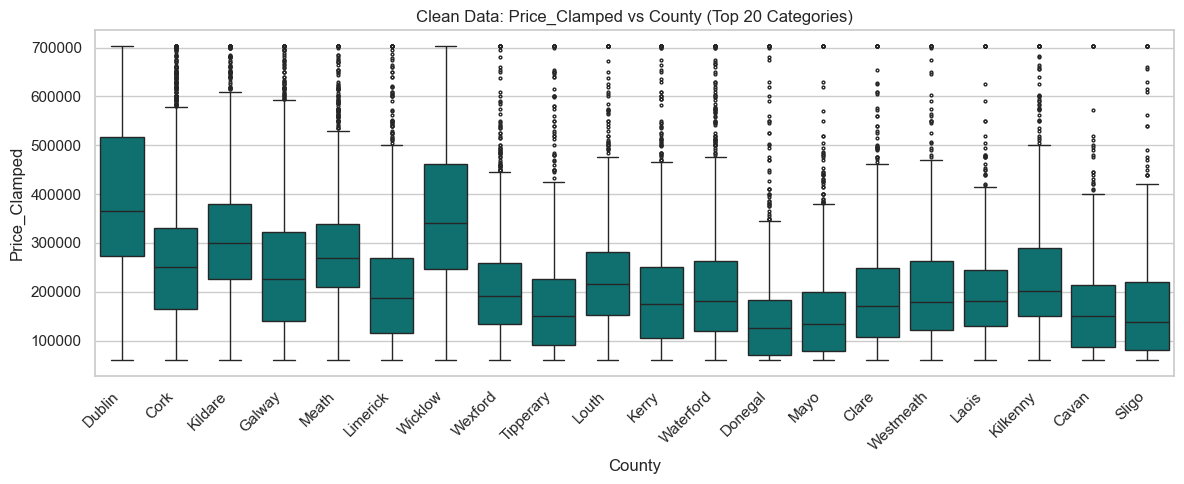

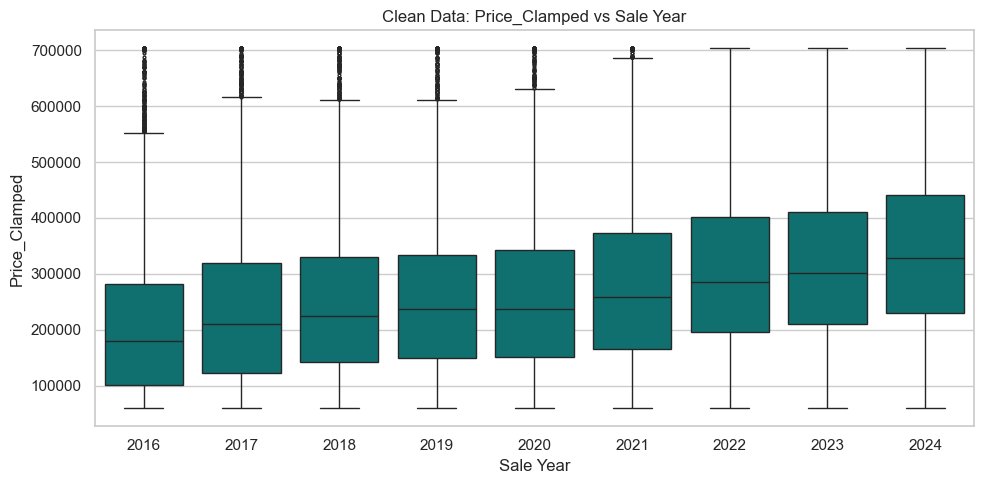

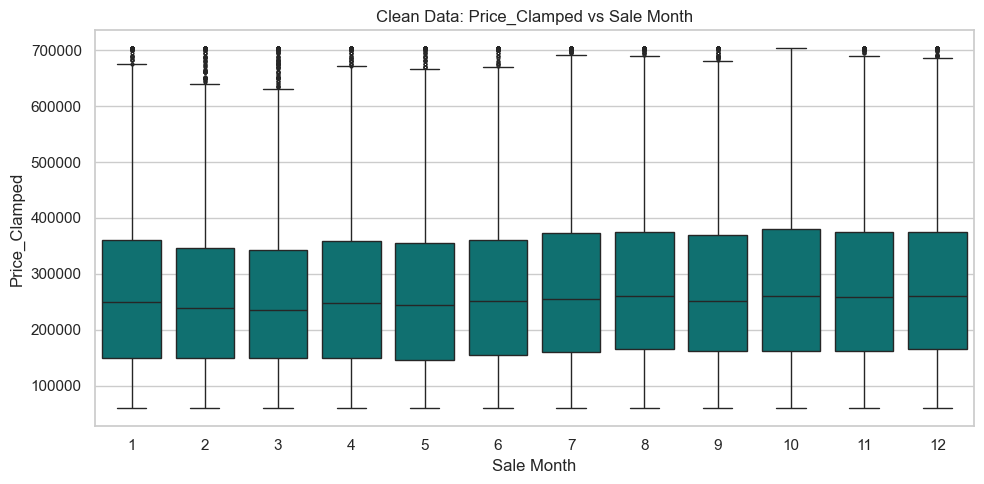

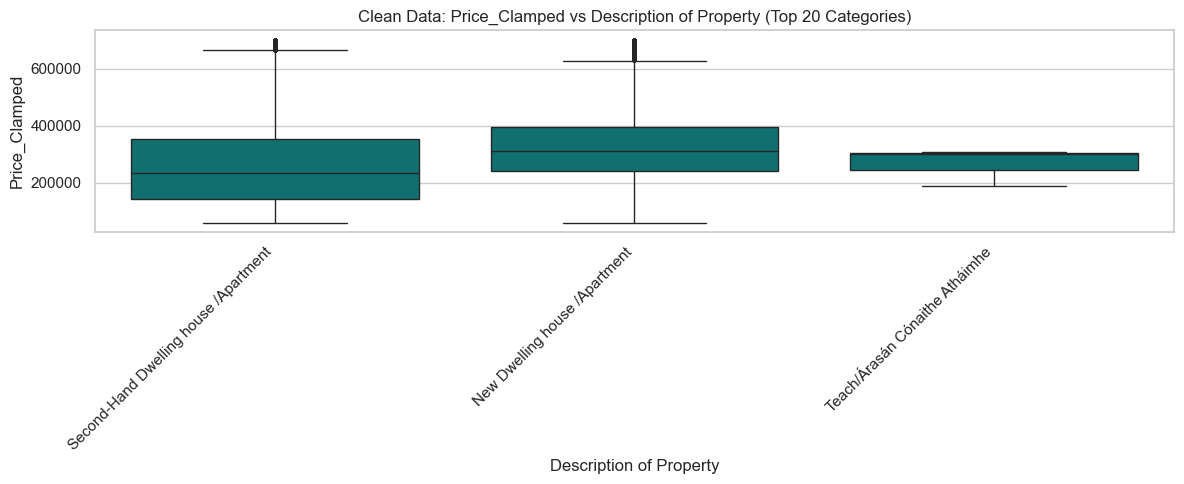

,Feature,Status,Reason,File
0,County,plotted,ok,feature_pair_plots_clean_final/boxplot_clean_C...
1,Sale Year,plotted,ok,feature_pair_plots_clean_final/boxplot_clean_S...
2,Sale Month,plotted,ok,feature_pair_plots_clean_final/boxplot_clean_S...
3,Description of Property,plotted,ok,feature_pair_plots_clean_final/boxplot_clean_D...


Saved images folder: feature_pair_plots_clean_final


In [15]:
# 单元功能：使用 clean-final 数据重新做特征对分析并导出结果。
import re
from pathlib import Path

clean_csv = 'ppr-group-25208508-clean-final.csv'
df_clean = pd.read_csv(clean_csv)

target = 'Price_Clamped'
if target not in df_clean.columns:
    raise KeyError("Column 'Price_Clamped' not found in clean dataset")

df_clean[target] = pd.to_numeric(
    df_clean[target].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

requested_features = ['County', 'Sale Year', 'Sale Month', 'Description of Property']
selected_features = [c for c in requested_features if c in df_clean.columns]
missing_features = [c for c in requested_features if c not in df_clean.columns]
if missing_features:
    print('Missing features in clean data:', missing_features)

work_clean = df_clean.dropna(subset=[target]).copy()
for col in ['Sale Year', 'Sale Month']:
    if col in work_clean.columns:
        work_clean[col] = pd.to_numeric(work_clean[col], errors='coerce').astype('Int64').astype('category')

pair_rows_clean = []
for c in selected_features:
    s = work_clean[c]
    pair_rows_clean.append({
        'Feature': c,
        'Type': 'numeric' if pd.api.types.is_numeric_dtype(s) else 'categorical',
        'NonNull': int(s.notna().sum()),
        'Unique': int(s.nunique(dropna=True))
    })
pair_df_clean = pd.DataFrame(pair_rows_clean)
display(pair_df_clean)

PLOT_DIR_CLEAN = Path('feature_pair_plots_clean_final')
PLOT_DIR_CLEAN.mkdir(parents=True, exist_ok=True)
MAX_CATS = 20
MIN_NON_NULL = 50
plot_log_clean = []

def safe_name(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_')

for feature in selected_features:
    tmp = work_clean[[target, feature]].dropna().copy()

    if len(tmp) < MIN_NON_NULL:
        plot_log_clean.append({'Feature': feature, 'Status': 'skip', 'Reason': f'too few rows ({len(tmp)})', 'File': ''})
        continue

    if feature in ['Sale Year', 'Sale Month']:
        tmp[feature] = pd.to_numeric(tmp[feature], errors='coerce').astype('Int64')
        tmp = tmp.dropna(subset=[feature]).copy()
        tmp[feature] = tmp[feature].astype(int).astype(str)
        order = sorted(tmp[feature].unique(), key=lambda x: int(x))

        plt.figure(figsize=(10, 5))
        sns.boxplot(data=tmp, x=feature, y=target, order=order, color='teal', fliersize=2)
        plt.title(f'Clean Data: {target} vs {feature}')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.tight_layout()

    else:
        top_levels = tmp[feature].value_counts(dropna=True).head(MAX_CATS).index
        tmp = tmp[tmp[feature].isin(top_levels)].copy()
        if tmp[feature].nunique(dropna=True) < 2:
            plot_log_clean.append({'Feature': feature, 'Status': 'skip', 'Reason': 'categories < 2', 'File': ''})
            continue
        order = tmp[feature].value_counts().index

        plt.figure(figsize=(12, 5))
        sns.boxplot(data=tmp, x=feature, y=target, order=order, color='teal', fliersize=2)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Clean Data: {target} vs {feature} (Top {MAX_CATS} Categories)')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.tight_layout()

    file_path = PLOT_DIR_CLEAN / f"boxplot_clean_{safe_name(feature)}_vs_{safe_name(target)}.png"
    plt.savefig(file_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()

    plot_log_clean.append({'Feature': feature, 'Status': 'plotted', 'Reason': 'ok', 'File': str(file_path)})

plot_log_df_clean = pd.DataFrame(plot_log_clean)
display(plot_log_df_clean)

print('Saved images folder:', PLOT_DIR_CLEAN)



# 5) 新增特征试验（独立单元）


,Feature,Type,NonNull,Unique
0,is_apartment,numeric,53991,2
1,has_number,numeric,53991,2
2,dublin_district,categorical,53991,25
3,dublin_district_missing,numeric,53991,2
4,area_token,categorical,53991,14683
5,area_token_missing,numeric,53991,1
6,eircode_missing,numeric,53991,2
7,eircode_prefix,categorical,53991,154


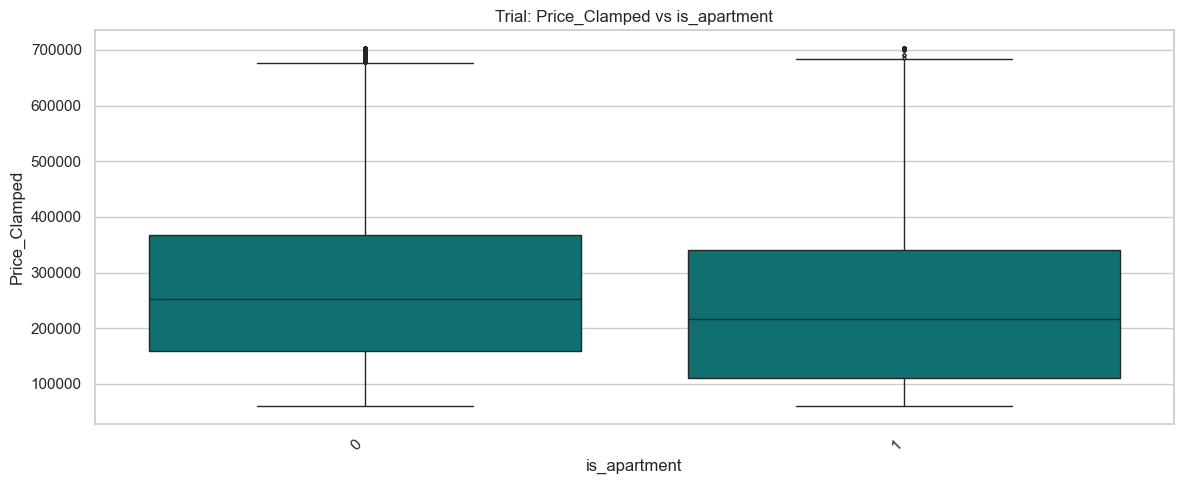

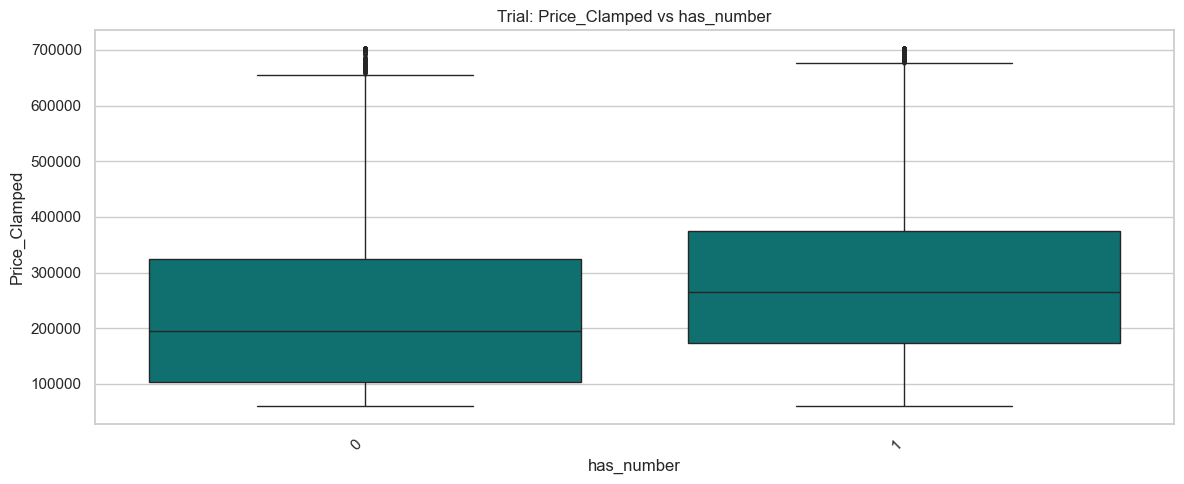

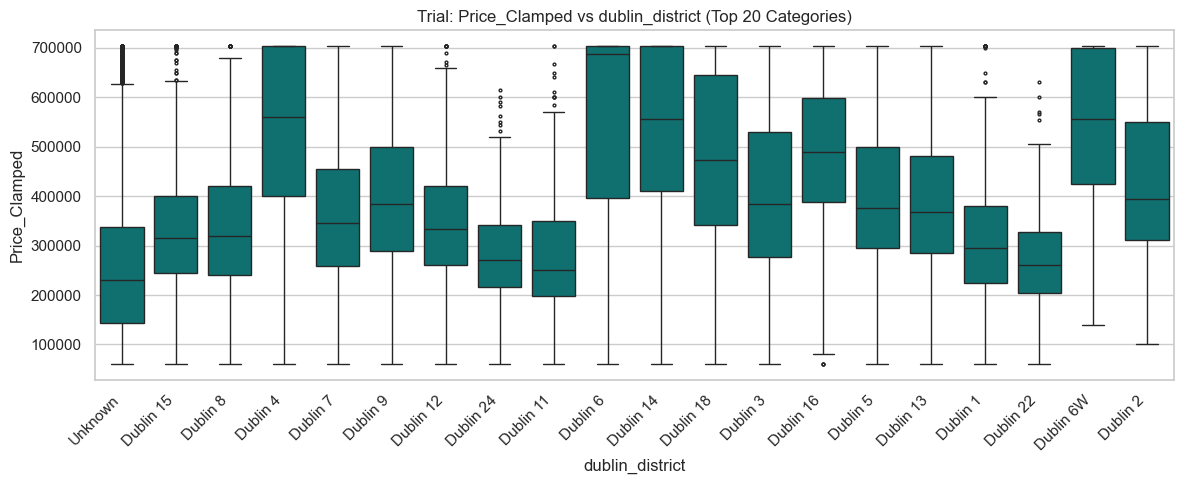

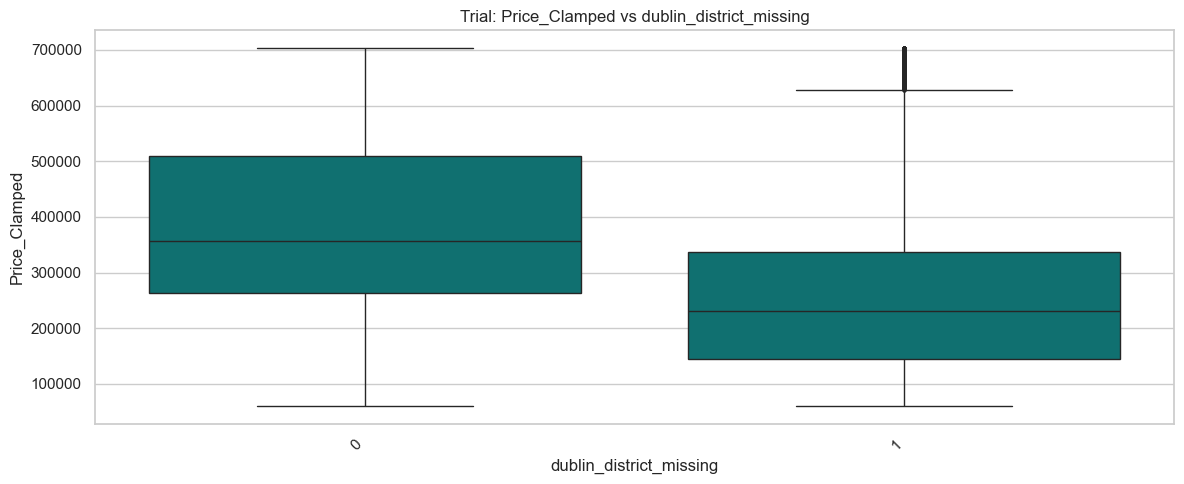

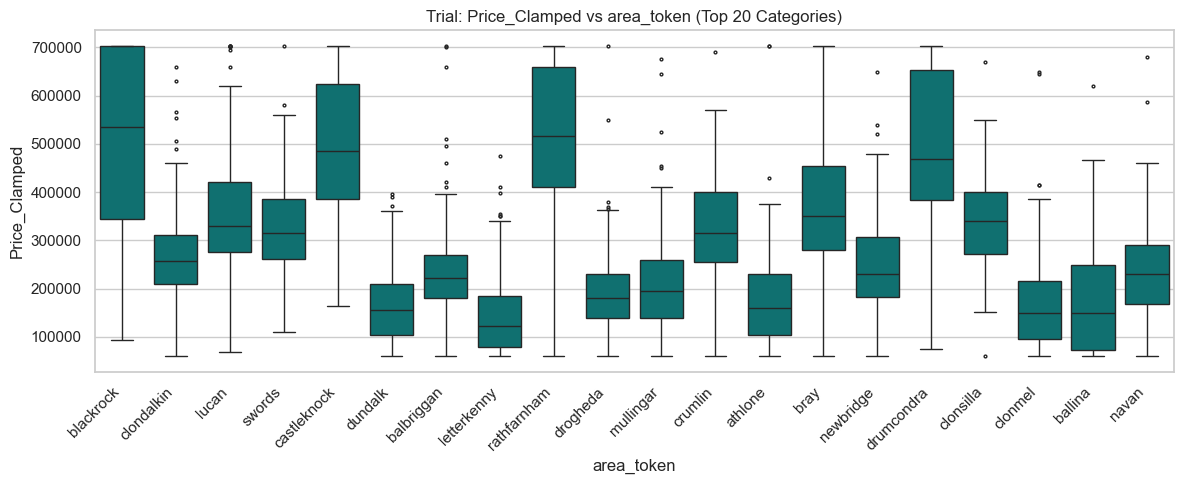

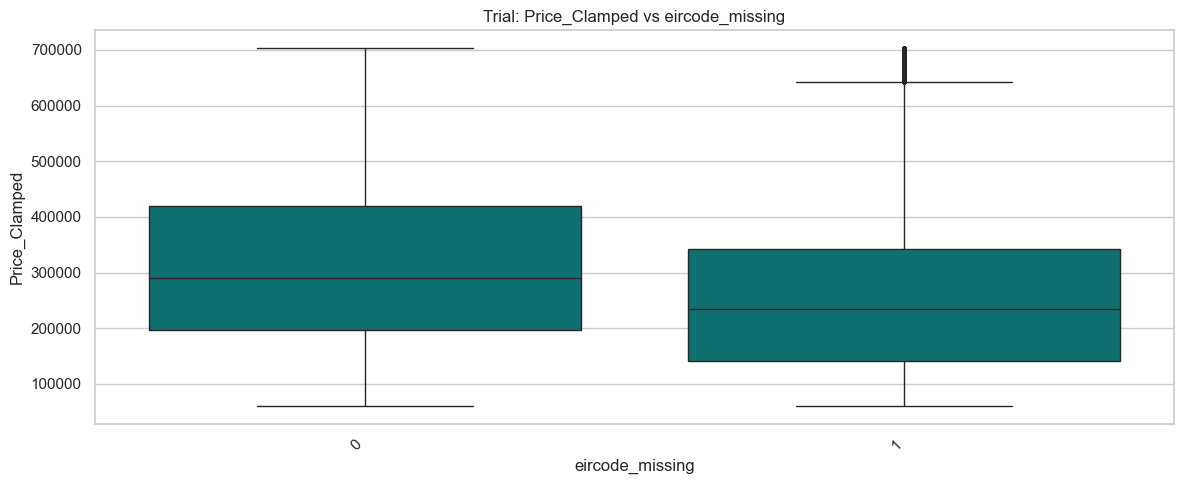

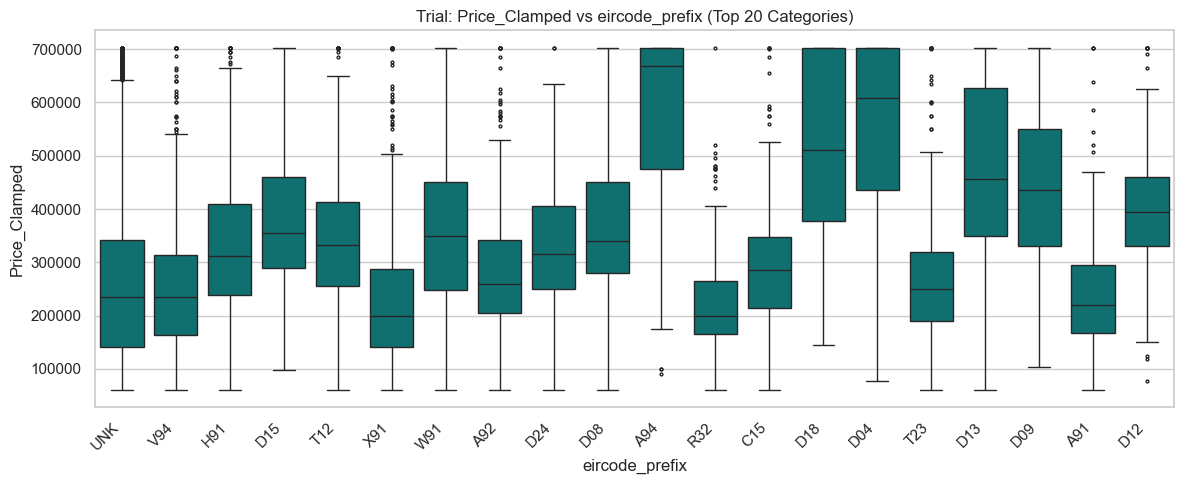

,Feature,Status,Reason,File
0,is_apartment,plotted,numeric low-cardinality grouped boxplot,feature_pair_plots_clean_trial_new_features/bo...
1,has_number,plotted,numeric low-cardinality grouped boxplot,feature_pair_plots_clean_trial_new_features/bo...
2,dublin_district,plotted,categorical boxplot,feature_pair_plots_clean_trial_new_features/bo...
3,dublin_district_missing,plotted,numeric low-cardinality grouped boxplot,feature_pair_plots_clean_trial_new_features/bo...
4,area_token,plotted,categorical boxplot,feature_pair_plots_clean_trial_new_features/bo...
5,area_token_missing,skip,numeric unique values < 2,
6,eircode_missing,plotted,numeric low-cardinality grouped boxplot,feature_pair_plots_clean_trial_new_features/bo...
7,eircode_prefix,plotted,categorical boxplot,feature_pair_plots_clean_trial_new_features/bo...


Saved images folder: feature_pair_plots_clean_trial_new_features


In [16]:
# 单元功能：仅针对新增特征做试验性特征对统计与箱线图（不影响已确认的4个特征结果）。
import re
from pathlib import Path

clean_csv = 'ppr-group-25208508-clean-final.csv'
df_trial = pd.read_csv(clean_csv)

target_trial = 'Price_Clamped'
if target_trial not in df_trial.columns:
    raise KeyError("Column 'Price_Clamped' not found in clean dataset")

df_trial[target_trial] = pd.to_numeric(
    df_trial[target_trial].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

requested_new_features = [
    'is_apartment',
    'has_number',
    'dublin_district',
    'dublin_district_missing',
    'area_token',
    'area_token_missing',
    'eircode_missing',
    'eircode_prefix',

]
requested_new_features = list(dict.fromkeys(requested_new_features))
selected_new_features = [c for c in requested_new_features if c in df_trial.columns and c != target_trial]
missing_new_features = [c for c in requested_new_features if c not in df_trial.columns]

if missing_new_features:
    print('Missing new features:', missing_new_features)
if target_trial in requested_new_features:
    print(f"Skip self-pair feature: {target_trial}")

work_trial = df_trial.dropna(subset=[target_trial]).copy()
for col in ['Sale Year', 'Sale Month']:
    if col in work_trial.columns:
        work_trial[col] = pd.to_numeric(work_trial[col], errors='coerce').astype('Int64').astype('category')

pair_rows_trial = []
for c in selected_new_features:
    s = work_trial[c]
    pair_rows_trial.append({
        'Feature': c,
        'Type': 'numeric' if pd.api.types.is_numeric_dtype(s) else 'categorical',
        'NonNull': int(s.notna().sum()),
        'Unique': int(s.nunique(dropna=True))
    })

pair_df_trial = pd.DataFrame(pair_rows_trial)
display(pair_df_trial)

PLOT_DIR_TRIAL = Path('feature_pair_plots_clean_trial_new_features')
PLOT_DIR_TRIAL.mkdir(parents=True, exist_ok=True)
MAX_CATS = 20
MIN_NON_NULL = 50
NUMERIC_UNIQUE_THRESHOLD = 20
NUMERIC_BINS = 10
plot_log_trial = []

def safe_name_trial(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_')

for feature in selected_new_features:
    tmp = work_trial[[target_trial, feature]].dropna().copy()

    if len(tmp) < MIN_NON_NULL:
        plot_log_trial.append({'Feature': feature, 'Status': 'skip', 'Reason': f'too few rows ({len(tmp)})', 'File': ''})
        continue

    feature_num = pd.to_numeric(tmp[feature], errors='coerce')
    is_numeric_feature = pd.api.types.is_numeric_dtype(work_trial[feature])

    if is_numeric_feature:
        tmp = tmp.assign(_feature_num=feature_num).dropna(subset=['_feature_num']).copy()
        n_unique = int(tmp['_feature_num'].nunique(dropna=True))

        if n_unique <= 1:
            plot_log_trial.append({'Feature': feature, 'Status': 'skip', 'Reason': 'numeric unique values < 2', 'File': ''})
            continue

        if n_unique <= NUMERIC_UNIQUE_THRESHOLD:
            tmp['_feature_plot'] = tmp['_feature_num'].round(6).astype(str)
            order = [str(v) for v in sorted(tmp['_feature_num'].unique())]
            reason = 'numeric low-cardinality grouped boxplot'
        else:
            q = min(NUMERIC_BINS, n_unique)
            tmp['_feature_plot'] = pd.qcut(tmp['_feature_num'], q=q, duplicates='drop').astype(str)
            order = tmp['_feature_plot'].value_counts().index
            reason = f'numeric qcut boxplot (q={q})'

        plt.figure(figsize=(12, 5))
        sns.boxplot(data=tmp, x='_feature_plot', y=target_trial, order=order, color='teal', fliersize=2)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Trial: {target_trial} vs {feature}')
        plt.xlabel(feature)
        plt.ylabel(target_trial)
        plt.tight_layout()

        file_path = PLOT_DIR_TRIAL / f"boxplot_trial_{safe_name_trial(feature)}_vs_{safe_name_trial(target_trial)}.png"
        plt.savefig(file_path, dpi=180, bbox_inches='tight')
        plt.show()
        plt.close()

        plot_log_trial.append({'Feature': feature, 'Status': 'plotted', 'Reason': reason, 'File': str(file_path)})
        continue

    top_levels = tmp[feature].value_counts(dropna=True).head(MAX_CATS).index
    tmp2 = tmp[tmp[feature].isin(top_levels)].copy()

    if tmp2[feature].nunique(dropna=True) < 2:
        plot_log_trial.append({'Feature': feature, 'Status': 'skip', 'Reason': 'categories < 2', 'File': ''})
        continue

    order = tmp2[feature].value_counts().index
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=tmp2, x=feature, y=target_trial, order=order, color='teal', fliersize=2)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Trial: {target_trial} vs {feature} (Top {MAX_CATS} Categories)')
    plt.xlabel(feature)
    plt.ylabel(target_trial)
    plt.tight_layout()

    file_path = PLOT_DIR_TRIAL / f"boxplot_trial_{safe_name_trial(feature)}_vs_{safe_name_trial(target_trial)}.png"
    plt.savefig(file_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()

    plot_log_trial.append({'Feature': feature, 'Status': 'plotted', 'Reason': 'categorical boxplot', 'File': str(file_path)})

plot_log_df_trial = pd.DataFrame(plot_log_trial)
display(plot_log_df_trial)

print('Saved images folder:', PLOT_DIR_TRIAL)



# 6) 新特征构造

**本阶段目标（当前进度）**

1. 构造至少 3 个工程特征（已完成）
   - `Sale Year`（由 `Date of Sale (dd/mm/yyyy)` 拆分）
   - `Sale Month`（由 `Date of Sale (dd/mm/yyyy)` 拆分）
   - `Price_Adjusted_VAT`（规则：当 `Description of Property == 'New Dwelling house /Apartment'` 且 `VAT Exclusive == Yes` 时，`Price * 1.135`，否则保留原价）

2. 避免数据泄漏（已明确）
   - 新特征会完整保留到数据集中；
   - 其中 `Price_Adjusted_VAT` 由价格计算得到，后续建模时不直接作为预测输入，避免目标泄漏。

3. 说明设计动机与领域知识依据（已完成）
   - `Sale Year`：反映年度趋势（通胀/市场周期）；
   - `Sale Month`：反映季节性波动；
   - VAT 调整规则：保证“新房且 VAT Exclusive=Yes”记录在业务口径上的价格一致性。

4. 关于“提升预测价值”的验证（延后）
   - 由于当前尚未进入统一模型训练阶段，本节不宣称效果提升；
   - 预测性能验证将在 Part 5 通过统一模型、hold-out 测试与交叉验证完成。

5. 输出包含新特征的数据集 CSV（本节完成）
   - 导出文件：`ppr-group-25208508-train-feature-engineered.csv`。



In [18]:
# 单元功能：仅做新特征构造与导出（不在本节进行模型训练验证）。
import numpy as np
import pandas as pd

# 1) 读取原始训练数据
src_csv = 'ppr-group-25208508-train.csv'
df_fe = pd.read_csv(src_csv).copy()

# 2) 价格清洗
price_col = 'Price (€)'
df_fe[price_col] = pd.to_numeric(
    df_fe[price_col].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

# 3) 特征一/二：Sale Year, Sale Month（从成交日期拆分）
date_col = 'Date of Sale (dd/mm/yyyy)'
df_fe[date_col] = pd.to_datetime(df_fe[date_col], dayfirst=True, errors='coerce')
df_fe['Sale Year'] = df_fe[date_col].dt.year.astype('Int64')
df_fe['Sale Month'] = df_fe[date_col].dt.month.astype('Int64')

# 4) 特征三：VAT 调整价格（业务规则）
# Rule: New Dwelling + VAT Exclusive=Yes -> Price * 1.135
is_new_dwelling = df_fe['Description of Property'].astype(str).str.strip().eq('New Dwelling house /Apartment')
vat_yes = df_fe['VAT Exclusive'].astype(str).str.strip().str.upper().isin(['YES', 'Y'])
vat_mask = is_new_dwelling & vat_yes

df_fe['vat_adjusted_flag'] = vat_mask.astype(int)
df_fe['VAT_Adjustment_Multiplier'] = np.where(vat_mask, 1.135, 1.0)
df_fe['Price_Adjusted_VAT'] = df_fe[price_col] * df_fe['VAT_Adjustment_Multiplier']

# 5) 本节只展示构造结果摘要（不做模型效果验证）
summary_df = pd.DataFrame([
    {
        'Feature': 'Sale Year',
        'NonNull': int(df_fe['Sale Year'].notna().sum()),
        'Unique': int(df_fe['Sale Year'].nunique(dropna=True)),
        'Note': 'Derived from Date of Sale'
    },
    {
        'Feature': 'Sale Month',
        'NonNull': int(df_fe['Sale Month'].notna().sum()),
        'Unique': int(df_fe['Sale Month'].nunique(dropna=True)),
        'Note': 'Derived from Date of Sale'
    },
    {
        'Feature': 'Price_Adjusted_VAT',
        'NonNull': int(df_fe['Price_Adjusted_VAT'].notna().sum()),
        'Unique': int(df_fe['Price_Adjusted_VAT'].nunique(dropna=True)),
        'Note': 'Price * 1.135 when New Dwelling and VAT Exclusive=Yes'
    }
])
display(summary_df)
print('VAT adjusted rows:', int(df_fe['vat_adjusted_flag'].sum()))

# 6) 导出包含新特征的数据集 CSV
out_csv = 'ppr-group-25208508-train-feature-engineered.csv'
df_fe.to_csv(out_csv, index=False)
print('Saved:', out_csv)
print('Rows:', len(df_fe), 'Columns:', len(df_fe.columns))



,Feature,NonNull,Unique,Note
0,Sale Year,54000,9,Derived from Date of Sale
1,Sale Month,54000,12,Derived from Date of Sale
2,Price_Adjusted_VAT,54000,7306,Price * 1.135 when New Dwelling and VAT Exclus...


VAT adjusted rows: 9514
Saved: ppr-group-25208508-train-feature-engineered.csv
Rows: 54000 Columns: 14
